In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import random
from pycocotools.coco import COCO

from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CocoDetection

print(f"CUDA? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


CUDA? True
GPU: NVIDIA GeForce GTX 1070 Ti


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

coco_api = COCO("annotations/instances_train2017.json")
val_coco_api = COCO("annotations/instances_val2017.json")
cat_ids = sorted(coco_api.getCatIds())
cat_id_to_idx = {cat_id: idx for idx, cat_id in enumerate(cat_ids)}

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = CocoDetection(
    root = "train2017",
    annFile = "annotations/instances_train2017.json",
    transform = transform
)

val_dataset = CocoDetection(
    root = "val2017",
    annFile = "annotations/instances_val2017.json",
    transform = transform
)

train_indices = random.sample(range(len(train_dataset)), 5000)
val_indices = random.sample(range(len(val_dataset)), 1000)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

def collate_fn(batch):
    images, targets = zip(*batch)

    return torch.stack(images, 0), targets

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

loading annotations into memory...
Done (t=12.08s)
creating index...
index created!
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
loading annotations into memory...
Done (t=12.20s)
creating index...
index created!
loading annotations into memory...
Done (t=0.65s)
creating index...
index created!


In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes=80):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

        self.bbox_regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Linear(512, 4),
        )

    def forward(self, x):
        x = self.features(x)
        class_out = self.classifier(x)
        bbox_out = self.bbox_regressor(x)
        return class_out, bbox_out


model = CNN().to(device)

criterion_class = nn.CrossEntropyLoss()
criterion_bbox = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=4)

num_epochs = 4

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_loss_class = 0.0
    train_loss_bbox = 0.0

    for images, targets in train_loader:
        images = images.to(device)

        class_labels = []
        bbox_labels = []

        for target in targets:
            if len(target) > 0:
                img_id = target[0]["image_id"]
                img_info = coco_api.loadImgs(img_id)[0]
                w, h = img_info["width"], img_info["height"]

                x, y, bw, bh = target[0]["bbox"]
                bbox_norm = [x / w, y / h, bw / w, bh / h]

                cat_id = target[0]["category_id"]
                class_labels.append(cat_id_to_idx[cat_id])
                bbox_labels.append(bbox_norm)
            else:
                class_labels.append(0)
                bbox_labels.append([0, 0, 0, 0])

        class_labels = torch.tensor(class_labels, dtype=torch.long).to(device)
        bbox_labels = torch.tensor(bbox_labels, dtype=torch.float32).to(device)

        optimizer.zero_grad()

        class_out, bbox_out = model(images)

        loss_class = criterion_class(class_out, class_labels)
        loss_bbox = criterion_bbox(bbox_out, bbox_labels)
        loss = loss_class + loss_bbox

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loss_class += loss_class.item()
        train_loss_bbox += loss_bbox.item()

    model.eval()
    val_loss = 0.0
    val_loss_class = 0.0
    val_loss_bbox = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)

            class_labels = []
            bbox_labels = []

            for target in targets:
                if len(target) > 0:
                    img_id = target[0]["image_id"]
                    img_info = val_coco_api.loadImgs(img_id)[0]
                    w, h = img_info["width"], img_info["height"]

                    x, y, bw, bh = target[0]["bbox"]
                    bbox_norm = [x / w, y / h, bw / w, bh / h]

                    cat_id = target[0]["category_id"]
                    class_labels.append(cat_id_to_idx[cat_id])
                    bbox_labels.append(bbox_norm)
                else:
                    class_labels.append(0)
                    bbox_labels.append([0, 0, 0, 0])

            class_labels = torch.tensor(class_labels, dtype=torch.long).to(device)
            bbox_labels = torch.tensor(bbox_labels, dtype=torch.float32).to(device)

            class_out, bbox_out = model(images)

            loss_class = criterion_class(class_out, class_labels)
            loss_bbox = criterion_bbox(bbox_out, bbox_labels)
            loss = loss_class + loss_bbox

            val_loss += loss.item()
            val_loss_class += loss_class.item()
            val_loss_bbox += loss_bbox.item()

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} "
          f"(cls: {train_loss_class/len(train_loader):.4f}, bbox: {train_loss_bbox/len(train_loader):.4f}) | "
          f"Val Loss: {val_loss/len(val_loader):.4f} "
          f"(cls: {val_loss_class/len(val_loader):.4f}, bbox: {val_loss_bbox/len(val_loader):.4f})")
    scheduler.step()
    print(f"  Current LR: {optimizer.param_groups[0]['lr']:.6f}")



def xywh_to_xyxy(bbox):
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.eval()
metric = MeanAveragePrecision()

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)

        class_out, bbox_out = model(images)

        preds = []
        for i in range(len(images)):
            pred_box = xywh_to_xyxy(bbox_out[i].cpu().tolist())
            preds.append({
                "boxes": torch.tensor([pred_box], dtype=torch.float32),
                "scores": torch.softmax(class_out[i], dim=0).max().unsqueeze(0).cpu(),
                "labels": class_out[i].argmax().unsqueeze(0).cpu()
            })

        gts = []
        for target in targets:
            if len(target) > 0:
                img_id = target[0]["image_id"]
                img_info = val_coco_api.loadImgs(img_id)[0]
                w, h = img_info["width"], img_info["height"]

                x, y, bw, bh = target[0]["bbox"]
                bbox_norm = [x / w, y / h, bw / w, bh / h]
                bbox = xywh_to_xyxy(bbox_norm)

                gts.append({
                    "boxes": torch.tensor([bbox], dtype=torch.float32),
                    "labels": torch.tensor([cat_id_to_idx[target[0]["category_id"]]], dtype=torch.long)
                })
            else:
                gts.append({
                    "boxes": torch.zeros((0, 4), dtype=torch.float32),
                    "labels": torch.zeros(0, dtype=torch.long)
                })

        metric.update(preds, gts)

results = metric.compute()
print(f"mAP:    {results['map']:.4f}")
print(f"mAP@50: {results['map_50']:.4f}")
print(f"mAP@75: {results['map_75']:.4f}")

Epoch 1/4 | Train Loss: 3.7470 (cls: 3.6898, bbox: 0.0572) | Val Loss: 3.6312 (cls: 3.5976, bbox: 0.0336)
  Current LR: 0.000854
Epoch 2/4 | Train Loss: 3.5015 (cls: 3.4670, bbox: 0.0345) | Val Loss: 3.5431 (cls: 3.5104, bbox: 0.0326)
  Current LR: 0.000500
Epoch 3/4 | Train Loss: 3.2656 (cls: 3.2324, bbox: 0.0332) | Val Loss: 3.3500 (cls: 3.3180, bbox: 0.0320)
  Current LR: 0.000146
Epoch 4/4 | Train Loss: 2.9654 (cls: 2.9350, bbox: 0.0305) | Val Loss: 3.3720 (cls: 3.3397, bbox: 0.0323)
  Current LR: 0.000000
mAP:    0.0000
mAP@50: 0.0001
mAP@75: 0.0000


In [19]:
transform_rcnn = transforms.Compose([transforms.ToTensor()])

val_dataset_rcnn = CocoDetection(
    root="val2017",
    annFile="annotations/instances_val2017.json",
    transform=transform_rcnn
)
val_subset_rcnn = Subset(val_dataset_rcnn, val_indices)

def collate_fn_rcnn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

val_loader_rcnn = DataLoader(
    val_subset_rcnn,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn_rcnn
)

import torchvision

model_frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model_frcnn.eval().to(device)

model_mrcnn = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model_mrcnn.eval().to(device)

def evaluate_rcnn(model, dataloader, score_threshold=0.5):
    metric = MeanAveragePrecision()

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]

            outputs = model(images)

            preds = []
            for out in outputs:
                keep = out["scores"] > score_threshold
                preds.append({
                    "boxes": out["boxes"][keep].cpu(),
                    "scores": out["scores"][keep].cpu(),
                    "labels": out["labels"][keep].cpu()
                })

            gts = []
            for target in targets:
                if len(target) > 0:
                    boxes = []
                    labels = []
                    for obj in target:
                        x, y, w, h = obj["bbox"]
                        boxes.append([x, y, x + w, y + h])
                        labels.append(obj["category_id"])
                    gts.append({
                        "boxes": torch.tensor(boxes, dtype=torch.float32),
                        "labels": torch.tensor(labels, dtype=torch.long)
                    })
                else:
                    gts.append({
                        "boxes": torch.zeros((0, 4), dtype=torch.float32),
                        "labels": torch.zeros(0, dtype=torch.long)
                    })

            metric.update(preds, gts)

    return metric.compute()

print("Faster R-CNN results:")
results_frcnn = evaluate_rcnn(model_frcnn, val_loader_rcnn)
print(f"mAP:    {results_frcnn['map']:.4f}")
print(f"mAP@50: {results_frcnn['map_50']:.4f}")
print(f"mAP@75: {results_frcnn['map_75']:.4f}")

print("\nMask R-CNN results:")
results_mrcnn = evaluate_rcnn(model_mrcnn, val_loader_rcnn)
print(f"mAP:    {results_mrcnn['map']:.4f}")
print(f"mAP@50: {results_mrcnn['map_50']:.4f}")
print(f"mAP@75: {results_mrcnn['map_75']:.4f}")


loading annotations into memory...
Done (t=0.37s)
creating index...
index created!


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Миро/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\Миро/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100.0%


Faster R-CNN results:
mAP:    0.3435
mAP@50: 0.5328
mAP@75: 0.3783

Mask R-CNN results:
mAP:    0.3537
mAP@50: 0.5388
mAP@75: 0.3881


In [21]:
from ultralytics import YOLO

model_yolo8 = YOLO("yolov8n.pt")
model_yolo11 = YOLO("yolo11n.pt")

from PIL import Image
import os

def evaluate_yolo(model, val_indices, val_dataset, coco_api, conf_threshold=0.25):
    metric = MeanAveragePrecision()

    for idx in val_indices:
        img, target = val_dataset[idx]


        img_id = val_dataset.ids[idx]
        img_info = val_coco_api.loadImgs(img_id)[0]
        img_path = os.path.join("val2017", img_info["file_name"])

        results = model(img_path, conf=conf_threshold, verbose=False)[0]

        boxes = results.boxes.xyxy.cpu()
        scores = results.boxes.conf.cpu()
        labels_yolo = results.boxes.cls.cpu().long()

        labels = torch.tensor([cat_ids[l] for l in labels_yolo], dtype=torch.long)

        preds = [{
            "boxes": boxes,
            "scores": scores,
            "labels": labels
        }]

        if len(target) > 0:
            gt_boxes = []
            gt_labels = []
            for obj in target:
                x, y, w, h = obj["bbox"]
                gt_boxes.append([x, y, x + w, y + h])
                gt_labels.append(obj["category_id"])
            gts = [{
                "boxes": torch.tensor(gt_boxes, dtype=torch.float32),
                "labels": torch.tensor(gt_labels, dtype=torch.long)
            }]
        else:
            gts = [{
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros(0, dtype=torch.long)
            }]

        metric.update(preds, gts)

    return metric.compute()

print("YOLOv8n results:")
results_y8 = evaluate_yolo(model_yolo8, val_indices, val_dataset, coco_api)
print(f"mAP:    {results_y8['map']:.4f}")
print(f"mAP@50: {results_y8['map_50']:.4f}")
print(f"mAP@75: {results_y8['map_75']:.4f}")

print("\nYOLO11n results:")
results_y11 = evaluate_yolo(model_yolo11, val_indices, val_dataset, coco_api)
print(f"mAP:    {results_y11['map']:.4f}")
print(f"mAP@50: {results_y11['map_50']:.4f}")
print(f"mAP@75: {results_y11['map_75']:.4f}")

YOLOv8n results:
mAP:    0.3064
mAP@50: 0.4176
mAP@75: 0.3369

YOLO11n results:
mAP:    0.3286
mAP@50: 0.4463
mAP@75: 0.3606


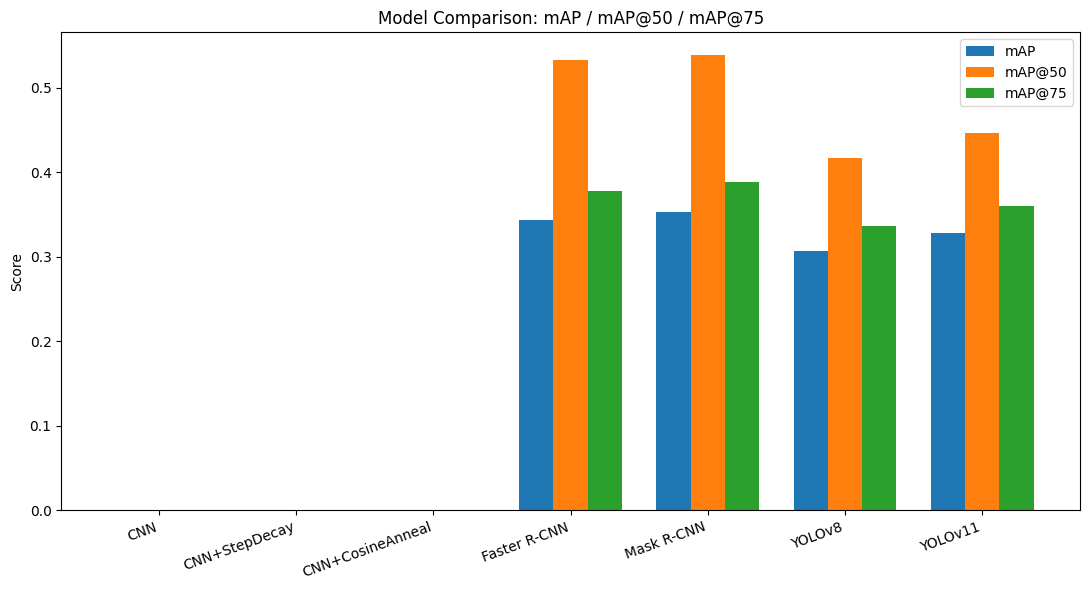

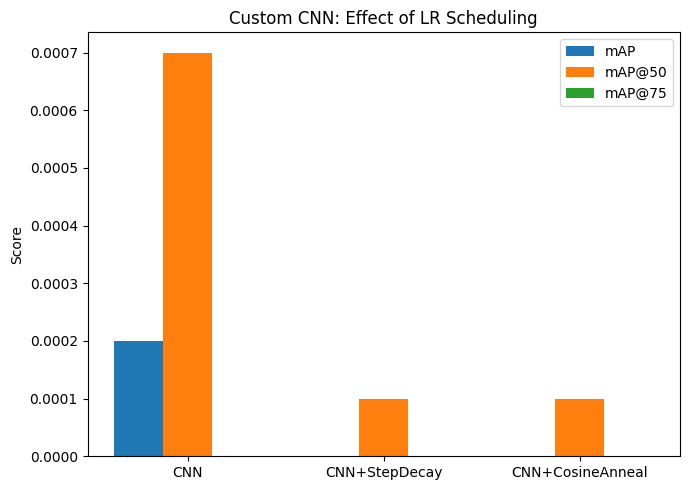

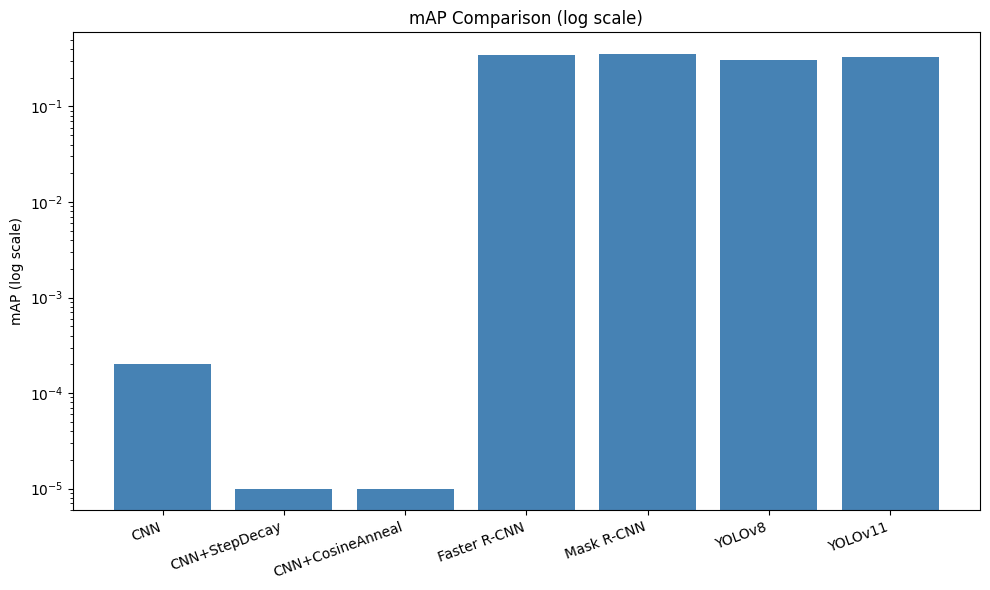

In [22]:
import numpy as np
import matplotlib.pyplot as plt

models = ["CNN", "CNN+StepDecay", "CNN+CosineAnneal", "Faster R-CNN", "Mask R-CNN", "YOLOv8", "YOLOv11"]
mAP    = [0.0002, 0.0000, 0.0000, 0.3435, 0.3537, 0.3064, 0.3286]
mAP50  = [0.0007, 0.0001, 0.0001, 0.5328, 0.5388, 0.4176, 0.4463]
mAP75  = [0.0000, 0.0000, 0.0000, 0.3783, 0.3881, 0.3369, 0.3606]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, mAP, width, label="mAP")
ax.bar(x, mAP50, width, label="mAP@50")
ax.bar(x + width, mAP75, width, label="mAP@75")

ax.set_ylabel("Score")
ax.set_title("Model Comparison: mAP / mAP@50 / mAP@75")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

cnn_models = ["CNN", "CNN+StepDecay", "CNN+CosineAnneal"]
cnn_mAP   = [0.0002, 0.0000, 0.0000]
cnn_mAP50 = [0.0007, 0.0001, 0.0001]
cnn_mAP75 = [0.0000, 0.0000, 0.0000]

x = np.arange(len(cnn_models))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width, cnn_mAP, width, label="mAP")
ax.bar(x, cnn_mAP50, width, label="mAP@50")
ax.bar(x + width, cnn_mAP75, width, label="mAP@75")

ax.set_ylabel("Score")
ax.set_title("Custom CNN: Effect of LR Scheduling")
ax.set_xticks(x)
ax.set_xticklabels(cnn_models)
ax.legend()
plt.tight_layout()
plt.show()

mAP_log = [v if v > 0 else 0.00001 for v in mAP]  # заместваш 0 с малка стойност за log scale

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, mAP_log, color='steelblue')
ax.set_yscale('log')
ax.set_ylabel("mAP (log scale)")
ax.set_title("mAP Comparison (log scale)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()